# Competitividad estatal y pobreza territorial
## Índice de Competitividad Estatal (IMCO) × ENIGH 2016–2018

**Narrativa central:** *"En México no se puede hablar de pobreza sin hablar de dónde naciste."*

Este notebook cruza el ICE (IMCO) con la ENIGH para responder:
¿La brecha de competitividad entre estados explica la brecha de ingreso?

**ODS vinculados:** ODS 1 (Fin de la Pobreza) · ODS 10 (Reducción de las Desigualdades)

> **Nota metodológica:** El ICE 2020 es la edición más reciente con base de datos pública.
> Contiene series anuales 2001–2018. Se usan los años 2016 y 2018 para cruzar
> con las olas equivalentes de la ENIGH.


## 1. Configuración

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import openpyxl
from pathlib import Path

DARK_BG = "#1a1a2e"
ACCENT  = "#e94560"
GOLD    = "#f5a623"
TEAL    = "#0f9b8e"
PURPLE  = "#7b68ee"

plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor":   DARK_BG,
    "text.color":       "white",
    "axes.labelcolor":  "white",
    "xtick.color":      "white",
    "ytick.color":      "white",
    "figure.dpi":       120,
    "figure.figsize":   (14, 8),
})

REGION_COLORS = {"Norte": TEAL, "Centro": GOLD, "Sur": ACCENT, "CDMX": PURPLE}

REGIONES = {
    "Aguascalientes": "Centro", "Baja California": "Norte",
    "Baja California Sur": "Norte", "Campeche": "Sur",
    "Coahuila": "Norte", "Colima": "Centro", "Chiapas": "Sur",
    "Chihuahua": "Norte", "Ciudad de México": "CDMX", "Durango": "Norte",
    "Guanajuato": "Centro", "Guerrero": "Sur", "Hidalgo": "Centro",
    "Jalisco": "Centro", "México": "Centro", "Michoacán": "Centro",
    "Morelos": "Centro", "Nayarit": "Norte", "Nuevo León": "Norte",
    "Oaxaca": "Sur", "Puebla": "Centro", "Querétaro": "Centro",
    "Quintana Roo": "Sur", "San Luis Potosí": "Norte", "Sinaloa": "Norte",
    "Sonora": "Norte", "Tabasco": "Sur", "Tamaulipas": "Norte",
    "Tlaxcala": "Centro", "Veracruz": "Sur", "Yucatán": "Sur",
    "Zacatecas": "Norte",
}

IMG_DIR  = Path("imagenes")
IMG_DIR.mkdir(exist_ok=True)
ICE_PATH = Path("datos/imco/ICE_2020_Base_datos.xlsx")

print(f"ICE 2020: {ICE_PATH.exists()}, {ICE_PATH.stat().st_size // 1024} KB")


ICE 2020: True, 6058 KB


## 2. Extracción de indicadores ICE por estado y año

El ICE 2020 organiza los datos en hojas `Ind (NN)` donde `Ind (N)` = año `2000+N`.
Extraemos los años 2016 (`Ind 16`) y 2018 (`Ind 18`).

Indicadores clave:
- **col 21** Pobreza (%)
- **col 40** Migración neta
- **col 59** Informalidad laboral (%)
- **col 60** Ingreso promedio de trabajadores (pesos)
- **col 61** Desigualdad salarial
- **col 68** PIB per cápita


In [2]:
# Columnas a extraer: (col_index, nombre_campo)
ICE_COLS = [
    (21, "ice_pobreza"),
    (27, "ice_analfabetismo"),
    (28, "ice_escolaridad"),
    (40, "ice_migracion_neta"),
    (59, "ice_informalidad"),
    (60, "ice_ingreso_promedio"),
    (61, "ice_desigualdad_salarial"),
    (62, "ice_bajo_bienestar"),
    (68, "ice_pib_pc"),
]

def extraer_ice_anio(filepath, ind_num):
    """Extrae indicadores de una hoja Ind (NN) del ICE 2020."""
    sheet = f"Ind ({ind_num:02d})"
    wb = openpyxl.load_workbook(filepath, read_only=True)
    ws = wb[sheet]
    rows = list(ws.iter_rows(min_row=9, max_row=42, values_only=True))
    wb.close()

    records = []
    for row in rows:
        if not row[1] or not isinstance(row[1], str):
            continue
        estado = row[1].strip()
        if estado in ("", "Entidad"):
            continue
        rec = {"estado": estado, "anio": 2000 + ind_num}
        for col_i, col_name in ICE_COLS:
            try:
                rec[col_name] = float(row[col_i]) if row[col_i] is not None else None
            except (TypeError, ValueError):
                rec[col_name] = None
        records.append(rec)
    return pd.DataFrame(records)

# Extraer 2016 y 2018
df16 = extraer_ice_anio(ICE_PATH, 16)
df18 = extraer_ice_anio(ICE_PATH, 18)
ice = pd.concat([df16, df18], ignore_index=True)

# Normalizar nombres de estado (ICE usa nombres completos)
NOMBRE_MAP = {
    "Ciudad de México": "Ciudad de México",
    "México": "México",
    "Michoacán": "Michoacán",
    "Coahuila": "Coahuila",
    "Veracruz": "Veracruz",
}
ice["region"] = ice["estado"].map(REGIONES).fillna("Otro")
ice["color"]  = ice["region"].map(REGION_COLORS).fillna("gray")

print(f"ICE extraído: {len(ice)} filas, {ice['anio'].unique()} años, {ice['estado'].nunique()} estados")
print(ice[["estado","anio","ice_pobreza","ice_informalidad","ice_ingreso_promedio"]].head(6).to_string(index=False))


ICE extraído: 64 filas, [2016 2018] años, 32 estados
             estado  anio  ice_pobreza  ice_informalidad  ice_ingreso_promedio
     Aguascalientes  2016    28.219218         43.919863           6159.252821
    Baja California  2016    22.232681         39.885598           7108.625874
Baja California Sur  2016    22.126035         39.037287           8771.305572
           Campeche  2016    43.767647         62.074658           6310.582036
           Coahuila  2016    24.815166         37.445828           6915.515622
             Colima  2016    33.631707         53.072865           6892.777603


## 3. Carga de ENIGH 2016 y 2018

Cargamos las dos olas de la ENIGH que coinciden con los años del ICE disponible.


In [3]:
ROOT = Path(".").resolve().parent  # hackods/
ENIGH_PATHS = {
    2016: ROOT / "Posibles Datos Melisa" / "HackODS"
          / "conjunto_de_datos_enigh_2016_ns_csv"
          / "conjunto_de_datos_concentradohogar_enigh_2016_ns"
          / "conjunto_de_datos"
          / "conjunto_de_datos_concentradohogar_enigh_2016_ns.csv",
    2018: ROOT / "Posibles Datos Melisa" / "HackODS"
          / "conjunto_de_datos_enigh_2018_ns_csv"
          / "conjunto_de_datos_concentradohogar_enigh_2018_ns"
          / "conjunto_de_datos"
          / "conjunto_de_datos_concentradohogar_enigh_2018_ns.csv",
}

ESTADOS_ENIGH = {
    1:"Aguascalientes", 2:"Baja California", 3:"Baja California Sur",
    4:"Campeche", 5:"Coahuila", 6:"Colima", 7:"Chiapas", 8:"Chihuahua",
    9:"Ciudad de México", 10:"Durango", 11:"Guanajuato", 12:"Guerrero",
    13:"Hidalgo", 14:"Jalisco", 15:"México", 16:"Michoacán",
    17:"Morelos", 18:"Nayarit", 19:"Nuevo León", 20:"Oaxaca",
    21:"Puebla", 22:"Querétaro", 23:"Quintana Roo", 24:"San Luis Potosí",
    25:"Sinaloa", 26:"Sonora", 27:"Tabasco", 28:"Tamaulipas",
    29:"Tlaxcala", 30:"Veracruz", 31:"Yucatán", 32:"Zacatecas",
}

COLS = ["ubica_geo", "factor", "tot_integ", "ing_cor", "ingtrab",
        "transfer", "bene_gob", "remesas"]

def weighted_median(vals, weights):
    s = sorted(zip(weights, vals))
    wt = sum(w for w, _ in s)
    cum = 0
    for w, v in s:
        cum += w
        if cum >= wt / 2:
            return v
    return float("nan")

frames_enigh = []
for year, path in ENIGH_PATHS.items():
    if not path.exists():
        print(f"  {year}: no encontrado en {path}")
        continue
    df = pd.read_csv(path, usecols=lambda c: c in COLS,
                     encoding="utf-8-sig", low_memory=False)
    df["anio"] = year
    df["cve_ent"] = df["ubica_geo"].map(
        lambda x: x // 10000000 if x >= 10000000 else x // 1000)
    df["estado"] = df["cve_ent"].map(ESTADOS_ENIGH)
    df["ing_pc_mes"] = df["ing_cor"] / df["tot_integ"].clip(lower=1) / 3
    frames_enigh.append(df)
    print(f"  {year}: {len(df):,} hogares, {df['estado'].nunique()} estados")

enigh_raw = pd.concat(frames_enigh, ignore_index=True)

# Agregar a nivel estado-año
def wmean(x, w): return np.average(x, weights=w) if w.sum() > 0 else np.nan

enigh = enigh_raw.groupby(["anio", "estado"]).apply(
    lambda g: pd.Series({
        "enigh_ing_pc_mediana": weighted_median(g["ing_pc_mes"].values, g["factor"].values),
        "enigh_ing_pc_media":   wmean(g["ing_pc_mes"], g["factor"]),
        "enigh_share_bene_gob": wmean(g["bene_gob"] / g["ing_cor"].clip(lower=1), g["factor"]),
        "n_hogares": len(g),
    }),
    include_groups=False
).reset_index()

print(f"\nENIGH agregada: {len(enigh)} filas")
print(enigh.head(4).to_string(index=False))


  2016: 70,311 hogares, 32 estados
  2018: 74,647 hogares, 32 estados

ENIGH agregada: 64 filas
 anio              estado  enigh_ing_pc_mediana  enigh_ing_pc_media  enigh_share_bene_gob  n_hogares
 2016      Aguascalientes           4752.785000         5235.193180              0.021212     2382.0
 2016     Baja California           7441.446667         6745.903232              0.009862     3583.0
 2016 Baja California Sur           1408.150000         7084.039277              0.022546     2251.0
 2016            Campeche           6808.973333         4809.816658              0.052863     1732.0


## 4. Cruce ICE × ENIGH

In [4]:
# Merge por estado y año
df = ice.merge(enigh, on=["estado", "anio"], how="inner")

print(f"Dataset cruzado: {len(df)} filas, {df['estado'].nunique()} estados, años: {sorted(df['anio'].unique())}")
print(df[["estado","anio","ice_informalidad","ice_ingreso_promedio","enigh_ing_pc_mediana"]].head(8).to_string(index=False))


Dataset cruzado: 64 filas, 32 estados, años: [np.int64(2016), np.int64(2018)]
             estado  anio  ice_informalidad  ice_ingreso_promedio  enigh_ing_pc_mediana
     Aguascalientes  2016         43.919863           6159.252821           4752.785000
    Baja California  2016         39.885598           7108.625874           7441.446667
Baja California Sur  2016         39.037287           8771.305572           1408.150000
           Campeche  2016         62.074658           6310.582036           6808.973333
           Coahuila  2016         37.445828           6915.515622           3607.210000
             Colima  2016         53.072865           6892.777603           2695.578333
            Chiapas  2016         79.347419           3938.495917           5069.950833
          Chihuahua  2016         35.452419           7452.759230           8020.158889


## 5. Informalidad laboral (ICE) vs Ingreso mediano (ENIGH)

¿Los estados con más informalidad tienen menos ingreso?
Dos fuentes independientes, misma historia.


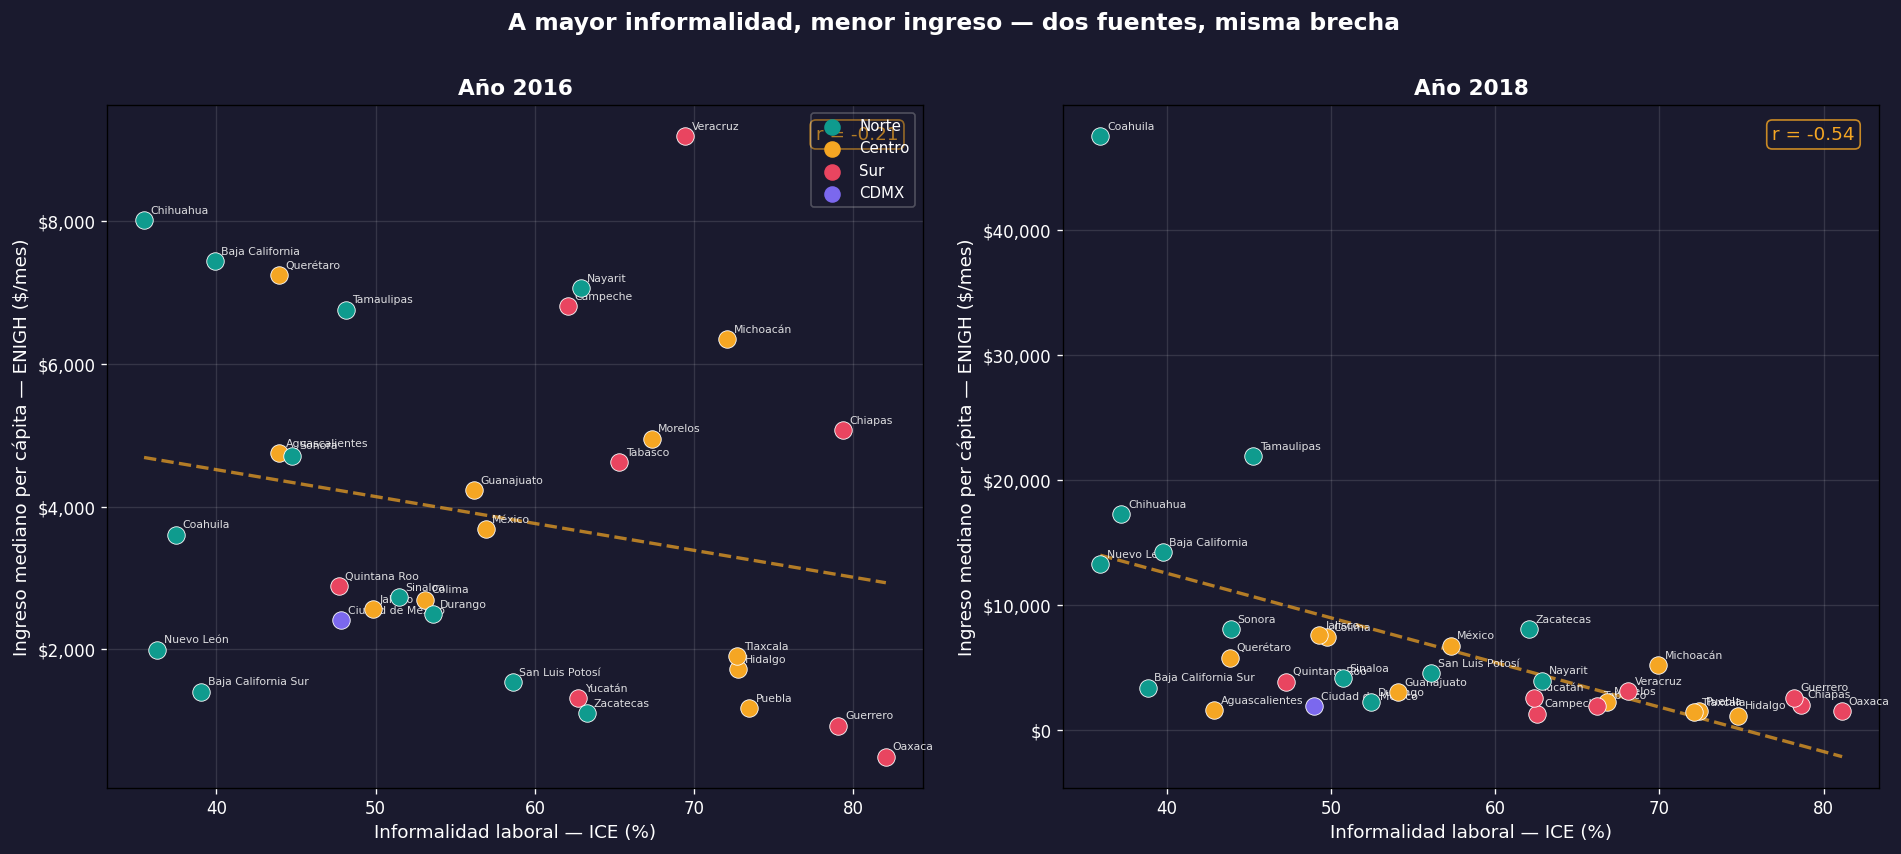

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, year in zip(axes, [2016, 2018]):
    sub = df[df["anio"] == year].dropna(subset=["ice_informalidad", "enigh_ing_pc_mediana"])
    for _, row in sub.iterrows():
        ax.scatter(row["ice_informalidad"], row["enigh_ing_pc_mediana"],
                   c=row["color"], s=110, zorder=5, edgecolors="white", linewidth=0.5)
        ax.annotate(row["estado"], (row["ice_informalidad"], row["enigh_ing_pc_mediana"]),
                    fontsize=6.5, color="white", alpha=0.85,
                    xytext=(4, 4), textcoords="offset points")

    z = np.polyfit(sub["ice_informalidad"], sub["enigh_ing_pc_mediana"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sub["ice_informalidad"].min(), sub["ice_informalidad"].max(), 100)
    ax.plot(x_line, p(x_line), "--", color=GOLD, alpha=0.7, linewidth=2)

    corr = sub["ice_informalidad"].corr(sub["enigh_ing_pc_mediana"])
    ax.text(0.97, 0.97, f"r = {corr:.2f}", transform=ax.transAxes,
            fontsize=11, color=GOLD, ha="right", va="top",
            bbox=dict(boxstyle="round", facecolor=DARK_BG, edgecolor=GOLD, alpha=0.8))

    ax.set_title(f"Año {year}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Informalidad laboral — ICE (%)", fontsize=11)
    ax.set_ylabel("Ingreso mediano per cápita — ENIGH ($/mes)", fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.grid(True, alpha=0.12, color="white")

for reg, col in REGION_COLORS.items():
    axes[0].scatter([], [], c=col, s=80, label=reg)
axes[0].legend(loc="upper right", fontsize=9, framealpha=0.3)

fig.suptitle("A mayor informalidad, menor ingreso — dos fuentes, misma brecha",
             fontsize=14, fontweight="bold", color="white", y=1.01)
plt.tight_layout()
plt.savefig(IMG_DIR / "ice_informalidad_vs_ingreso.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. ¿Quién mejoró entre 2016 y 2018?

Cambio en informalidad (ICE) vs cambio en ingreso mediano (ENIGH).
Los estados que reducen informalidad, ¿ganan más ingreso?


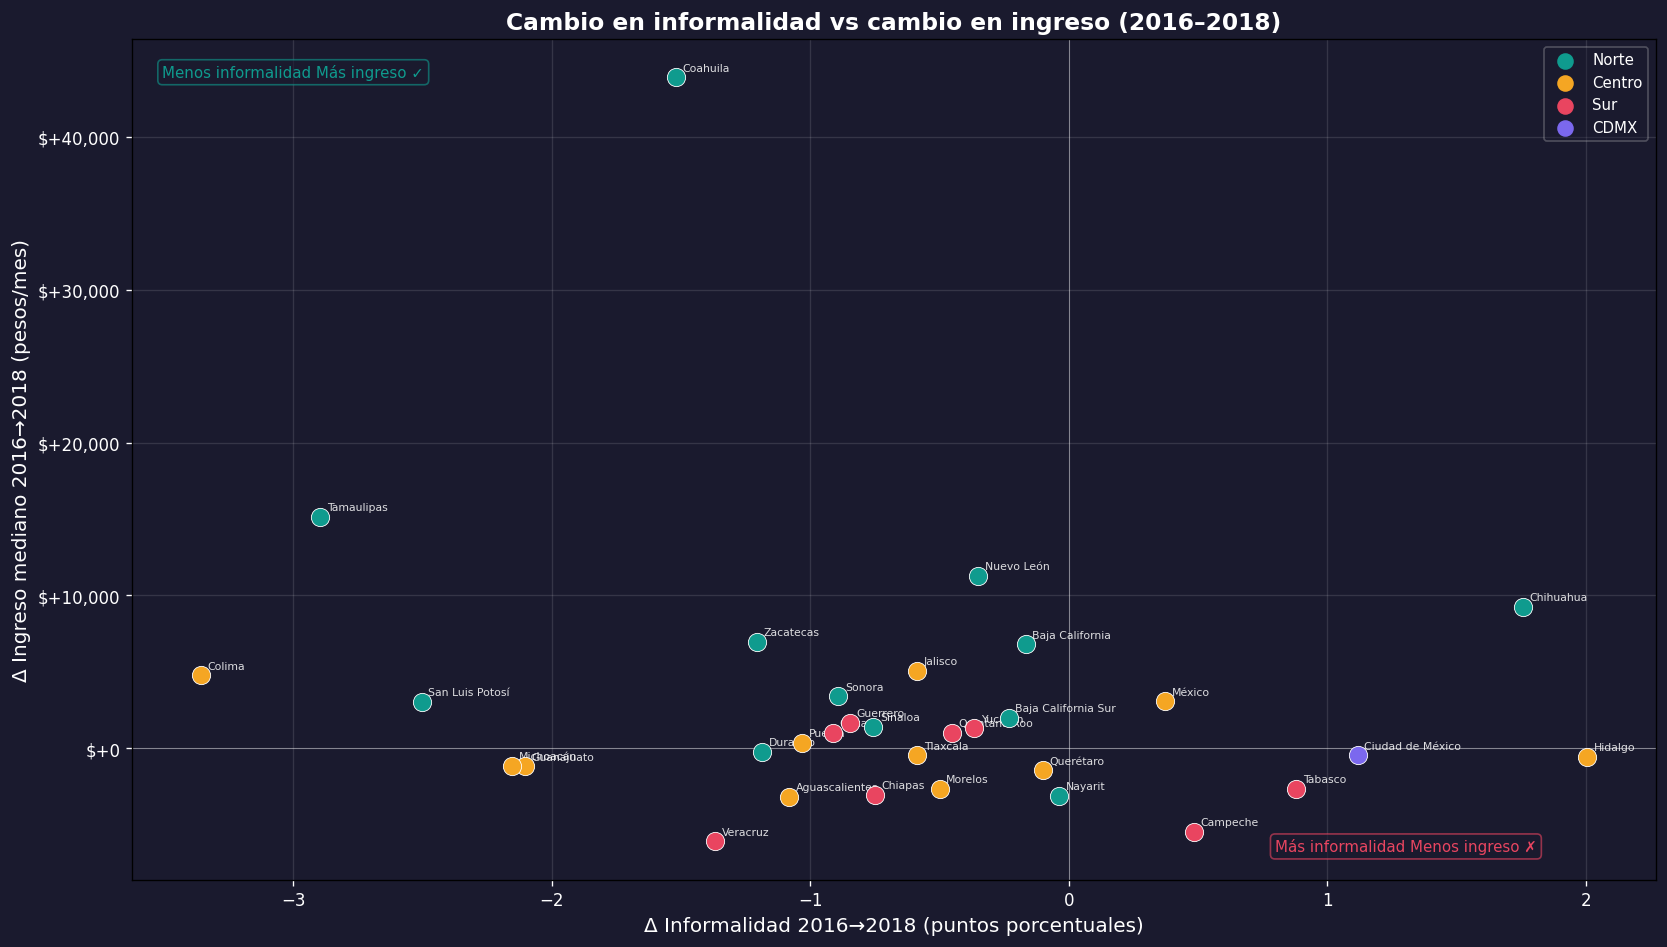

In [7]:
# Pivot a nivel estado: calcular cambios 2016→2018
d16 = df[df["anio"] == 2016].set_index("estado")
d18 = df[df["anio"] == 2018].set_index("estado")
estados_comunes = d16.index.intersection(d18.index)

cambios = pd.DataFrame({
    "delta_informal":  d18.loc[estados_comunes, "ice_informalidad"] - d16.loc[estados_comunes, "ice_informalidad"],
    "delta_ingreso":   d18.loc[estados_comunes, "enigh_ing_pc_mediana"] - d16.loc[estados_comunes, "enigh_ing_pc_mediana"],
    "region":          d16.loc[estados_comunes, "region"],
    "color":           d16.loc[estados_comunes, "color"],
    "inf_2016":        d16.loc[estados_comunes, "ice_informalidad"],
}).reset_index()

fig, ax = plt.subplots(figsize=(14, 8))

for _, row in cambios.iterrows():
    ax.scatter(row["delta_informal"], row["delta_ingreso"],
               c=row["color"], s=120, zorder=5, edgecolors="white", linewidth=0.5)
    ax.annotate(row["estado"], (row["delta_informal"], row["delta_ingreso"]),
                fontsize=6.5, color="white", alpha=0.85,
                xytext=(4, 4), textcoords="offset points")

ax.axhline(0, color="white", linewidth=0.6, alpha=0.4)
ax.axvline(0, color="white", linewidth=0.6, alpha=0.4)

ax.text(0.02, 0.97, "Menos informalidad Más ingreso ✓", transform=ax.transAxes,
        fontsize=9, color=TEAL, va="top",
        bbox=dict(boxstyle="round", facecolor=DARK_BG, edgecolor=TEAL, alpha=0.6))
ax.text(0.75, 0.03, "Más informalidad Menos ingreso ✗", transform=ax.transAxes,
        fontsize=9, color=ACCENT, va="bottom",
        bbox=dict(boxstyle="round", facecolor=DARK_BG, edgecolor=ACCENT, alpha=0.6))

ax.set_xlabel("Δ Informalidad 2016→2018 (puntos porcentuales)", fontsize=12)
ax.set_ylabel("Δ Ingreso mediano 2016→2018 (pesos/mes)", fontsize=12)
ax.set_title("Cambio en informalidad vs cambio en ingreso (2016–2018)",
             fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:+,.0f}"))
ax.grid(True, alpha=0.12, color="white")

for reg, col in REGION_COLORS.items():
    ax.scatter([], [], c=col, s=80, label=reg)
ax.legend(fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.savefig(IMG_DIR / "ice_cambio_informal_ingreso.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Brecha Norte–Sur: competitividad y bienestar

Comparación regional de indicadores clave para 2018.


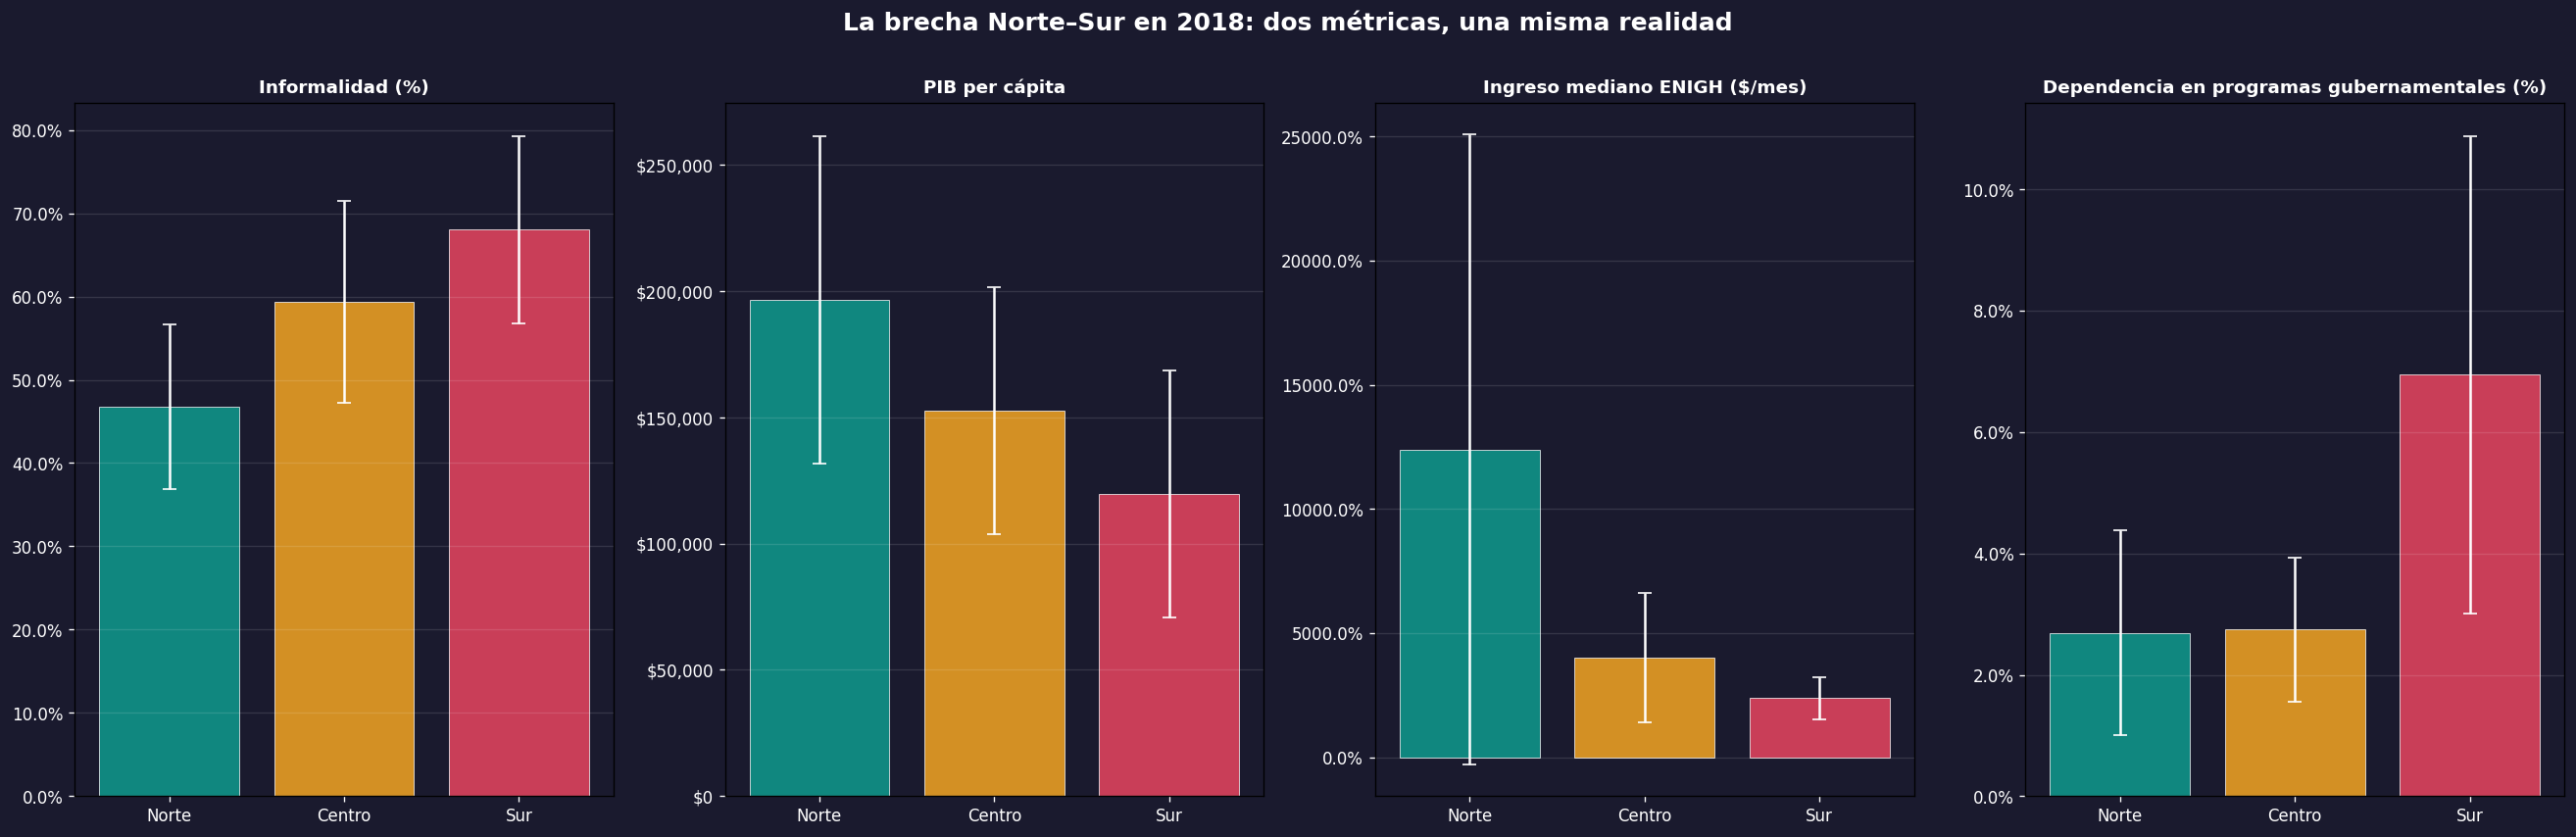

In [8]:
df18 = df[df["anio"] == 2018].copy()
df18 = df18[df18["region"].isin(["Norte", "Centro", "Sur"])]

metricas = [
    ("ice_informalidad",    "Informalidad (%)"),
    ("ice_pib_pc",          "PIB per cápita"),
    ("enigh_ing_pc_mediana","Ingreso mediano ENIGH ($/mes)"),
    ("enigh_share_bene_gob","Dependencia en programas gubernamentales (%)"),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 7))

for ax, (col, label) in zip(axes, metricas):
    for region in ["Norte", "Centro", "Sur"]:
        sub = df18[df18["region"] == region][col].dropna()
        ax.bar(region, sub.mean(), color=REGION_COLORS[region],
               edgecolor="white", linewidth=0.5, alpha=0.85)
        ax.errorbar(region, sub.mean(), yerr=sub.std(),
                    fmt="none", color="white", capsize=4, linewidth=1.5)

    ax.set_title(label, fontsize=11, fontweight="bold", color="white")
    ax.grid(True, alpha=0.12, axis="y", color="white")
    ax.tick_params(axis="x", labelsize=10)

    if "ingreso" in col or "pib" in col or "promedio" in col:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    elif "share" in col:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))

fig.suptitle("La brecha Norte–Sur en 2018: dos métricas, una misma realidad",
             fontsize=15, fontweight="bold", color="white", y=1.01)
plt.tight_layout()
plt.savefig(IMG_DIR / "ice_brecha_regional_2018.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Hallazgos

In [9]:
print("=" * 65)
print("HALLAZGOS: COMPETITIVIDAD ESTATAL Y POBREZA TERRITORIAL")
print("=" * 65)

df18 = df[df["anio"] == 2018].dropna(subset=["ice_informalidad", "enigh_ing_pc_mediana"])

r_inf = df18["ice_informalidad"].corr(df18["enigh_ing_pc_mediana"])
r_pib = df18["ice_pib_pc"].corr(df18["enigh_ing_pc_mediana"])

print(f"\n1. CORRELACION informalidad (ICE) vs ingreso mediano (ENIGH): {r_inf:.3f}")
print(f"   CORRELACION PIB pc (ICE)       vs ingreso mediano (ENIGH): {r_pib:.3f}")
print(f"   -> Dos fuentes independientes confirman la misma brecha")

for region in ["Norte", "Centro", "Sur"]:
    sub = df18[df18["region"] == region]
    print(f"\n2. {region}:")
    print(f"   Informalidad promedio: {sub['ice_informalidad'].mean():.1f}%")
    print(f"   Ingreso mediano ENIGH: ${sub['enigh_ing_pc_mediana'].mean():,.0f}/mes")

print(f"\n3. BRECHA NORTE-SUR:")
norte = df18[df18["region"] == "Norte"]["enigh_ing_pc_mediana"].mean()
sur   = df18[df18["region"] == "Sur"]["enigh_ing_pc_mediana"].mean()
print(f"   Ingreso mediano Norte: ${norte:,.0f}/mes")
print(f"   Ingreso mediano Sur:   ${sur:,.0f}/mes")
print(f"   El Norte gana {norte/sur:.1f}x más que el Sur")

print("\n" + "=" * 65)
print("CONCLUSION: La informalidad laboral es el eslabón entre")
print("competitividad institucional y pobreza. Los estados menos")
print("competitivos tienen más informalidad y menos ingreso.")
print("Nacer en esos estados determina tu acceso al mercado formal.")
print("=" * 65)


HALLAZGOS: COMPETITIVIDAD ESTATAL Y POBREZA TERRITORIAL

1. CORRELACION informalidad (ICE) vs ingreso mediano (ENIGH): -0.544
   CORRELACION PIB pc (ICE)       vs ingreso mediano (ENIGH): 0.333
   -> Dos fuentes independientes confirman la misma brecha

2. Norte:
   Informalidad promedio: 46.7%
   Ingreso mediano ENIGH: $12,397/mes

2. Centro:
   Informalidad promedio: 59.4%
   Ingreso mediano ENIGH: $4,001/mes

2. Sur:
   Informalidad promedio: 68.0%
   Ingreso mediano ENIGH: $2,389/mes

3. BRECHA NORTE-SUR:
   Ingreso mediano Norte: $12,397/mes
   Ingreso mediano Sur:   $2,389/mes
   El Norte gana 5.2x más que el Sur

CONCLUSION: La informalidad laboral es el eslabón entre
competitividad institucional y pobreza. Los estados menos
competitivos tienen más informalidad y menos ingreso.
Nacer en esos estados determina tu acceso al mercado formal.


## Fuentes de datos

| Fuente | Institución | Años utilizados |
|--------|-------------|-----------------|
| Índice de Competitividad Estatal (ICE) | IMCO | 2016, 2018 (vía ICE 2020) |
| ENIGH — concentradohogar | INEGI | 2016, 2018 |

*ASHIRA - HackODS UNAM 2026 - ODS 1 + ODS 10*
